# Correlation between agents — the independence the design is buying

The whole case for eleven single-driver analysts instead of one generalist rests on
breadth: under `IR ≈ IC · √breadth`, independent bets compound and correlated ones do not.
With breadth fixed at roughly twelve bets a year, an information ratio of 1.0 needs
**IC ≈ 0.289** — where a cross-sectional equity book is content with 0.05.

That makes cross-analyst correlation **load-bearing, not decorative**. If the analysts
agree, the panel is one bet wearing eleven hats and the √breadth term is a fiction.

There is also a specific thing to test. A prior round found that a *shared* text feed
collapsed cross-analyst independence from 0.15 to 0.81 — agents reading the same words
converge. This board partitions the text per driver precisely to avoid that, and the four
arms let us price whether the partition works.

Degraded views are excluded and **carried views are blanked**: a replayed view is not an
independent observation, and counting it as one would flatter every number here.

In [1]:
import sys, os, glob, math, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath("..")); sys.path.insert(0, ".")

import numpy as np, pandas as pd, matplotlib.pyplot as plt
import _viz as V; V.use_style()

from src.layered.evaluation.runs import load_run
from src.layered.evaluation import ic_diagnostics as D
from src.layered.evaluation import attribution as A

BOARD, ARM = "../reports/hk", "anon_cue"
ARMS = ["none", "anon_cue", "anon_full", "plain"]
LABEL = {"none": "none\n(numbers only)", "anon_cue": "anon_cue\n(driver extract)",
         "anon_full": "anon_full\n(whole statement)", "plain": "plain\n(LEAK ARM)"}

runs = {}
for f in sorted(glob.glob(f"{BOARD}/*.jsonl")):
    st = os.path.basename(f)[:-6]
    for a in ARMS:
        if st.endswith("_" + a):
            runs[(st[:-(len(a)+1)], a)] = load_run(f); break
DRIVERS = sorted({d for d, _ in runs})
IC = {(d, a): D.rank_ic(*[D.align(runs[(d,a)].signed.dropna(), runs[(d,a)].level.dropna())[c]
                          for c in ("s","y")])[1] for d, a in runs}
print(f"{len(runs)} legs · {len(DRIVERS)} analysts")

44 legs · 11 analysts


In [2]:
from src.layered.evaluation.cross_correlation import score_board, board_matrix

def arm_paths(arm):
    return [f"{BOARD}/{d}_{arm}.jsonl" for d in DRIVERS]

CC = {}
for arm in ARMS:
    try: CC[arm] = score_board(arm_paths(arm), arm=arm)
    except Exception as e: print(f"[skip] {arm}: {e}")
summary = pd.DataFrame([c.summary() for c in CC.values()])
display(summary.round(3))

,arm,mean_abs_corr,n_drivers,pairs_scored,pairs_dropped
0,none,0.111,11,36,19
1,anon_cue,0.097,11,36,19
2,anon_full,0.091,11,36,19
3,plain,0.112,11,36,19


## 1 — Does feeding text converge the panel?

The headline number is `mean_abs` — the mean absolute pairwise correlation of the signed
conviction streams. **Lower is more independent, and more independent is the point.**

If the prior finding generalised, this would climb from left to right as the text volume
grows. The partition is the design's defence against exactly that.

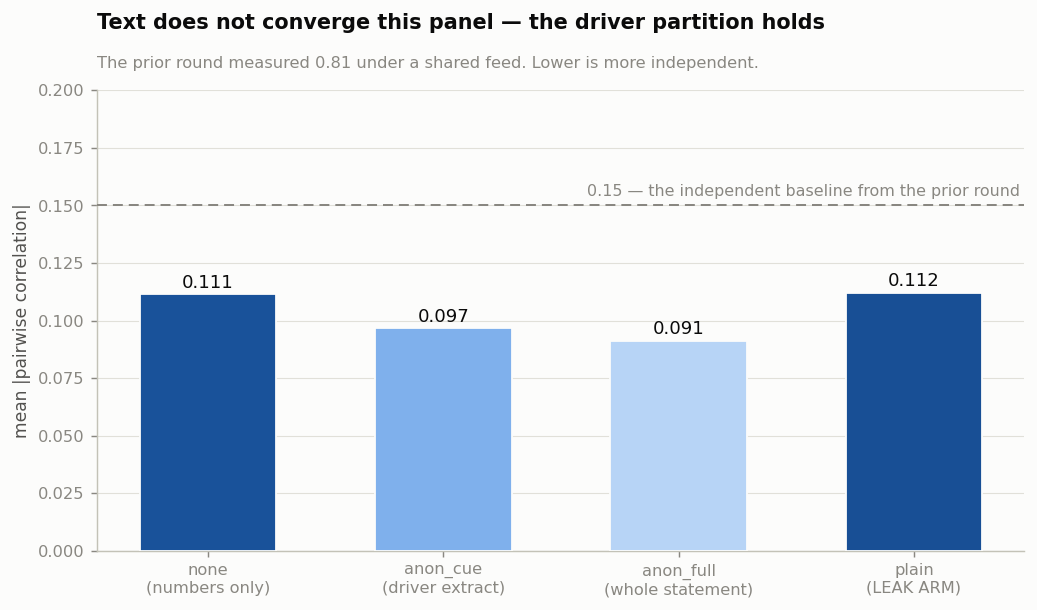

In [3]:
vals = [CC[a].mean_abs for a in ARMS if a in CC]
labs = [LABEL[a] for a in ARMS if a in CC]
fig, ax = plt.subplots(figsize=(9.2, 4.6))
ax.bar(range(len(vals)), vals, color=V.seq_colors(vals), width=.58, zorder=3,
       edgecolor=V.SURFACE, linewidth=1.0)
for i, v in enumerate(vals):
    ax.text(i, v + .003, f"{v:.3f}", ha="center", fontsize=10, color=V.INK)
ax.axhline(0.15, color=V.MUTED, lw=1.1, ls=(0, (5, 3)), zorder=4)
ax.annotate("0.15 — the independent baseline from the prior round", xy=(3.45, 0.15),
            xytext=(0, 5), textcoords="offset points", ha="right", fontsize=8.8, color=V.MUTED)
ax.set_xticks(range(len(labs))); ax.set_xticklabels(labs, fontsize=9)
ax.set_ylabel("mean |pairwise correlation|")
ax.set_ylim(0, max(max(vals) * 1.5, 0.2))
V.title(ax, "Text does not converge this panel — the driver partition holds",
        "The prior round measured 0.81 under a shared feed. Lower is more independent.")
V.grid(ax, "y"); plt.show()

## 2 — The correlation matrix

Signed conviction streams against each other, on the shipped arm. Diverging scale: blue
pairs move together, red move oppositely, near-white are independent. Pairs with too little
overlap are dropped rather than shown as zero — a thin pair reported as uncorrelated would
flatter the panel.

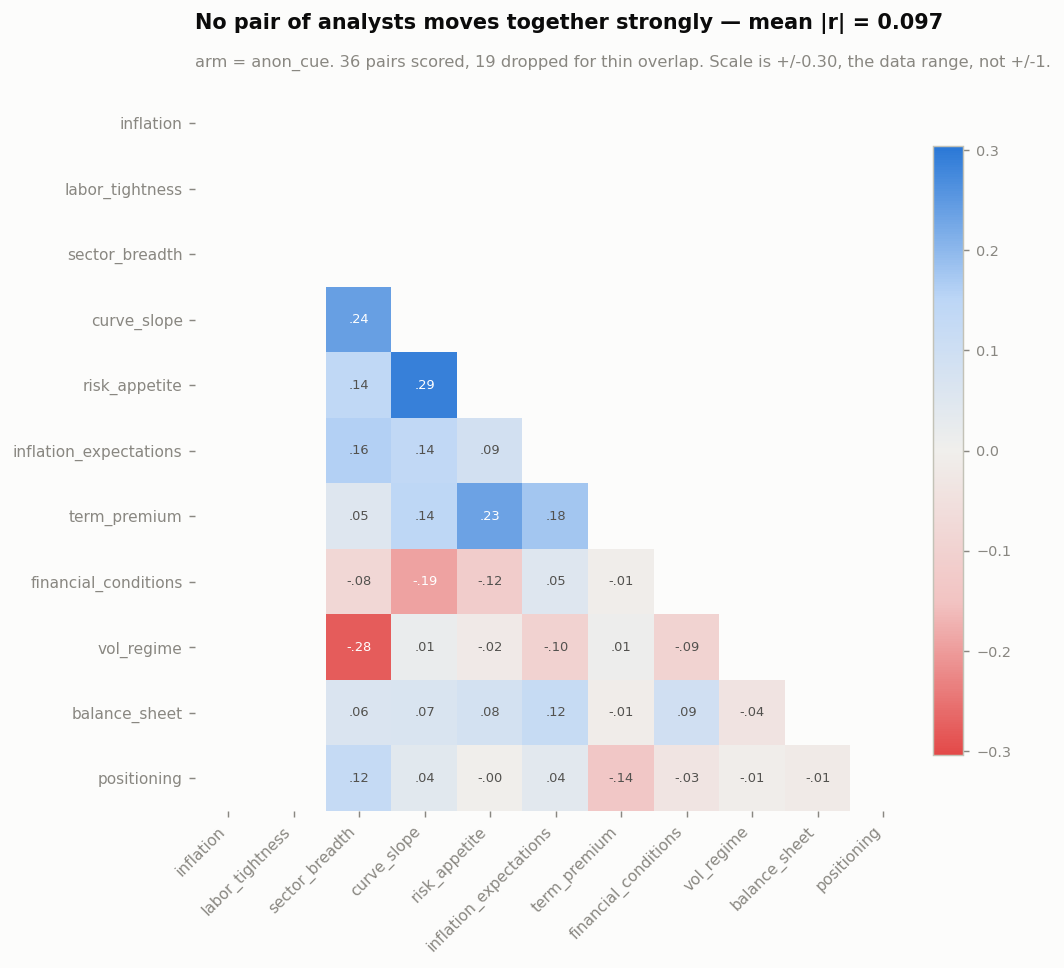

In [4]:
cc = CC[ARM]
M = cc.matrix.copy()
order = M.abs().mean().sort_values(ascending=False).index
M = M.loc[order, order]
# Mask the upper triangle AND the diagonal: r=1 with itself is not information, and at
# full-scale it dominates the colour range so the real structure reads as blank.
mask = np.triu(np.ones_like(M.values, dtype=bool), k=0)
Mv = np.where(mask, np.nan, M.values)
lim = float(np.nanmax(np.abs(Mv))) * 1.05      # scale to the data, not to +/-1

fig, ax = plt.subplots(figsize=(8.4, 7.2))
im = ax.imshow(Mv, cmap=V.DIV, vmin=-lim, vmax=lim)
ax.set_xticks(range(len(M))); ax.set_xticklabels(M.columns, rotation=45, ha="right", fontsize=8.5)
ax.set_yticks(range(len(M))); ax.set_yticklabels(M.index, fontsize=8.5)
for i in range(len(M)):
    for j in range(i + 1):
        v = M.values[i, j]
        if not np.isnan(v) and i != j:
            ax.text(j, i, f"{v:+.2f}".replace("+0.", ".").replace("-0.", "-."),
                    ha="center", va="center", fontsize=7.2,
                    color="white" if abs(v) > lim * .62 else V.INK2)
for sp in ax.spines.values(): sp.set_visible(False)
cb = fig.colorbar(im, ax=ax, pad=.02, fraction=.036); cb.ax.tick_params(labelsize=8)
V.title(ax, f"No pair of analysts moves together strongly — mean |r| = {cc.mean_abs:.3f}",
        f"arm = {ARM}. {cc.n_pairs_scored} pairs scored, {cc.n_pairs_dropped} dropped for thin overlap. "
        f"Scale is +/-{lim:.2f}, the data range, not +/-1.")
plt.show()

## 3 — The pairs that actually matter

Ranked by |r|. The top of this list is where the √breadth argument leaks, and one pair on
this board is a known artifact rather than a finding: **`curve_slope` and `risk_appetite`
are graded on the same economic quantity** — `risk_appetite`'s level feature is
`curve_slope_bp`, the 2s10s slope. They are one signal wearing two names, and they should
be reported as a duplicate rather than counted as evidence of convergence.

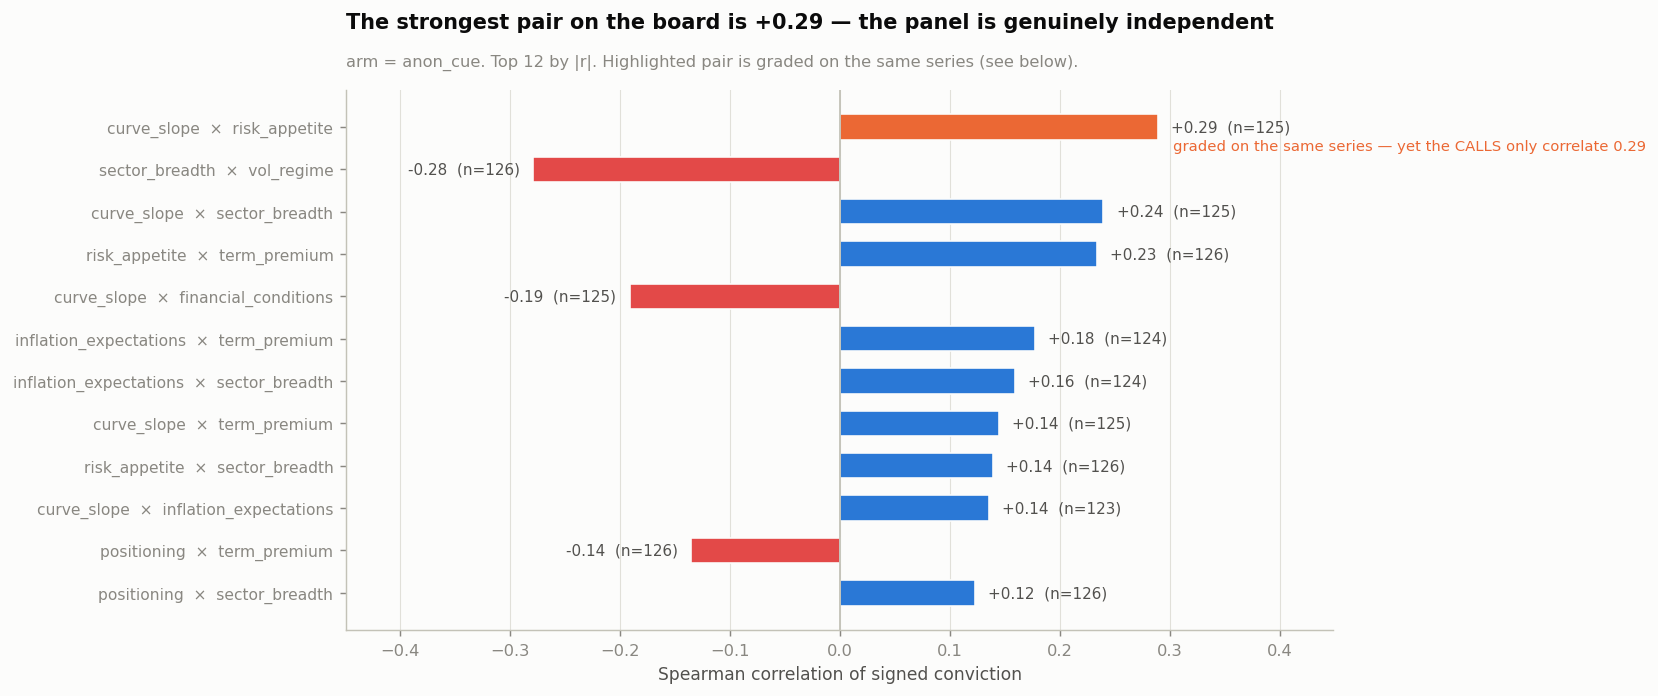

In [5]:
p = cc.pairs.sort_values("abs_r", ascending=False).head(12).iloc[::-1]
labels = [f"{a}  ×  {b}" for a, b in zip(p["a"], p["b"])]
dup = [(a == "curve_slope" and b == "risk_appetite") or (a == "risk_appetite" and b == "curve_slope")
       for a, b in zip(p["a"], p["b"])]
fig, ax = plt.subplots(figsize=(9.8, 5.4))
y = np.arange(len(p))
ax.barh(y, p["r"], color=[V.CAT[1] if d else (V.POS if r > 0 else V.NEG)
                          for d, r in zip(dup, p["r"])],
        height=.6, zorder=3, edgecolor=V.SURFACE, linewidth=.9)
ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=8.6)
for yi, (r_, n_, d_) in enumerate(zip(p["r"], p["n"], dup)):
    ax.text(r_ + (.012 if r_ >= 0 else -.012), yi, f"{r_:+.2f}  (n={n_})",
            va="center", ha="left" if r_ >= 0 else "right", fontsize=8.4, color=V.INK2)
    if d_: ax.annotate("graded on the same series — yet the CALLS only correlate 0.29",
                       (r_, yi), xytext=(8, -13), textcoords="offset points",
                       fontsize=8.2, color=V.CAT[1])
ax.axvline(0, color=V.AXIS, lw=1.0, zorder=4)
lim3 = float(p["abs_r"].max()) * 1.55
ax.set_xlim(-lim3, lim3); ax.set_xlabel("Spearman correlation of signed conviction")
V.title(ax, "The strongest pair on the board is +0.29 — the panel is genuinely independent",
        f"arm = {ARM}. Top 12 by |r|. Highlighted pair is graded on the same series (see below).")
V.grid(ax, "x"); plt.show()

## 4 — The duplicate that turned out not to be one

`risk_appetite`'s level feature is `curve_slope_bp` — the 2s10s slope — which is what
`curve_slope` is graded on. Their **outcome** series correlate **+0.95**: they are scored on
the same quantity, and that is a defect in the persona catalogue.

But their **calls** correlate only **+0.29**. Two analysts can be graded on one series and
still form independent views of it, and this is the distinction that matters here — the
breadth argument needs the *calls* to be independent, not the targets.

So removing one is a robustness check, not a correction. If the panel's independence rested
on double-counting, this would move.

,all 11,drop risk_appetite,pairs (11),pairs (10)
arm,,,,
none,0.111,0.108,36,28
anon_cue,0.097,0.090,36,28
anon_full,0.091,0.082,36,28
plain,0.112,0.102,36,28


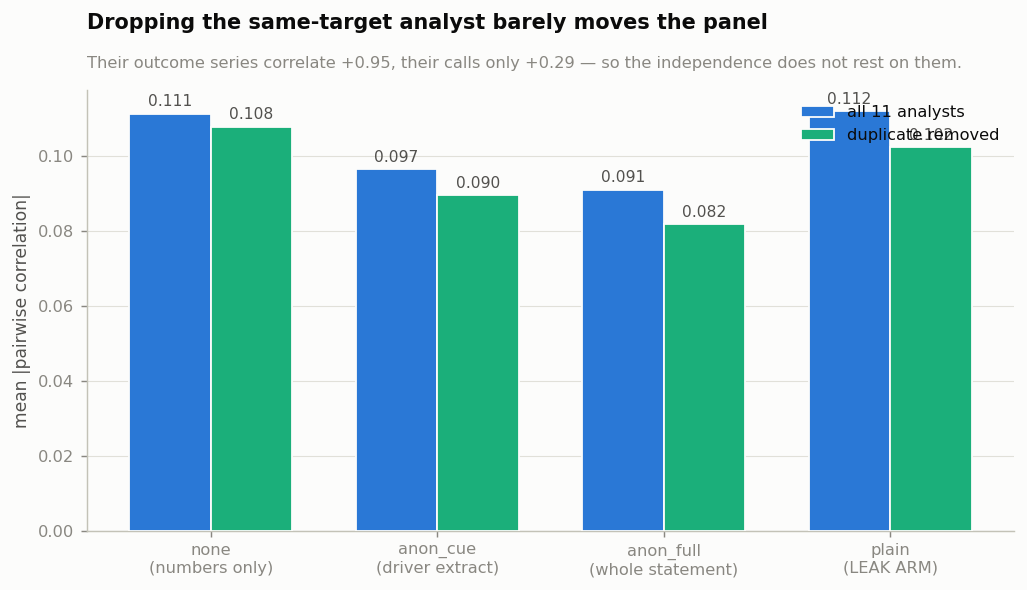

In [6]:
rows = []
for arm in ARMS:
    if arm not in CC: continue
    full = CC[arm]
    keep = [f"{d}_{arm}.jsonl" for d in DRIVERS if d != "risk_appetite"]
    trimmed = score_board([f"{BOARD}/{k}" for k in keep], arm=arm)
    rows.append({"arm": arm, "all 11": full.mean_abs, "drop risk_appetite": trimmed.mean_abs,
                 "pairs (11)": full.n_pairs_scored, "pairs (10)": trimmed.n_pairs_scored})
R = pd.DataFrame(rows).set_index("arm")
display(R.round(3))

x = np.arange(len(R)); w = .36
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x - w/2, R["all 11"], w, color=V.POS, zorder=3, label="all 11 analysts",
       edgecolor=V.SURFACE, linewidth=1)
ax.bar(x + w/2, R["drop risk_appetite"], w, color=V.CAT[2], zorder=3,
       label="duplicate removed", edgecolor=V.SURFACE, linewidth=1)
for i, (a_, b_) in enumerate(zip(R["all 11"], R["drop risk_appetite"])):
    ax.text(i - w/2, a_ + .002, f"{a_:.3f}", ha="center", fontsize=8.6, color=V.INK2)
    ax.text(i + w/2, b_ + .002, f"{b_:.3f}", ha="center", fontsize=8.6, color=V.INK2)
ax.set_xticks(x); ax.set_xticklabels([LABEL[a] for a in R.index], fontsize=9)
ax.set_ylabel("mean |pairwise correlation|"); ax.legend(loc="upper right")
V.title(ax, "Dropping the same-target analyst barely moves the panel",
        "Their outcome series correlate +0.95, their calls only +0.29 — so the independence "
        "does not rest on them.")
V.grid(ax, "y"); plt.show()

## What this can and cannot say

- **Correlation of the signed conviction streams**, not of the underlying drivers. Two
  analysts can be economically related while their *calls* stay independent, which is the
  quantity the breadth argument needs.
- **Carried views are blanked and degraded views excluded.** Counting a replay as an
  observation would flatter every number here.
- **Thin pairs are dropped, never zeroed** — reporting an under-observed pair as
  uncorrelated is the specific failure the predecessor implementation had.
- **55 pairs are scored**, so roughly 3 will clear |t|>2 by chance. Read the top of the
  ranking, not individual stars.
- `curve_slope` × `risk_appetite` **share a level feature**, so they are graded on the same
  quantity (outcome correlation +0.95). That is a catalogue defect worth fixing at source.
  It is *not* the same as their calls being correlated — those sit at +0.29, and the
  distinction is easy to conflate.